1️⃣ Setup and Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Optional: for pretty plots
import seaborn as sns
sns.set(style='whitegrid')

2️⃣ Define Paths & Load Data Info

In [5]:
# Dataset paths
no_path = "dataset/no"
yes_path = "dataset/yes"

# List files
no_images = sorted(os.listdir(no_path))
yes_images = sorted(os.listdir(yes_path))

print(f"Number of 'no' images: {len(no_images)}")
print(f"Number of 'yes' images: {len(yes_images)}")

Number of 'no' images: 1500
Number of 'yes' images: 1500


3️⃣ Quick Visualization of Random Samples

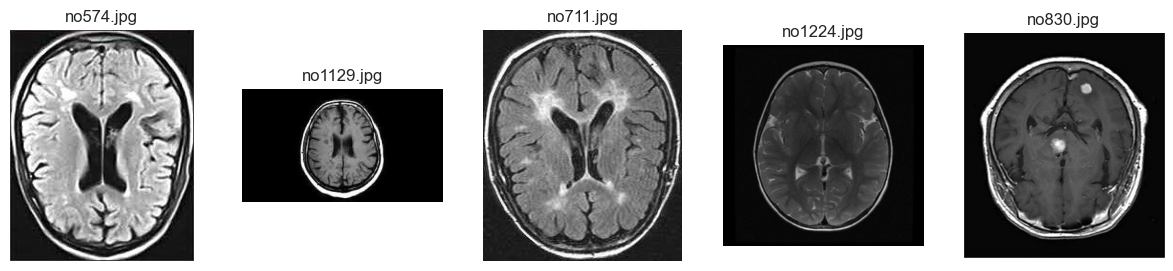

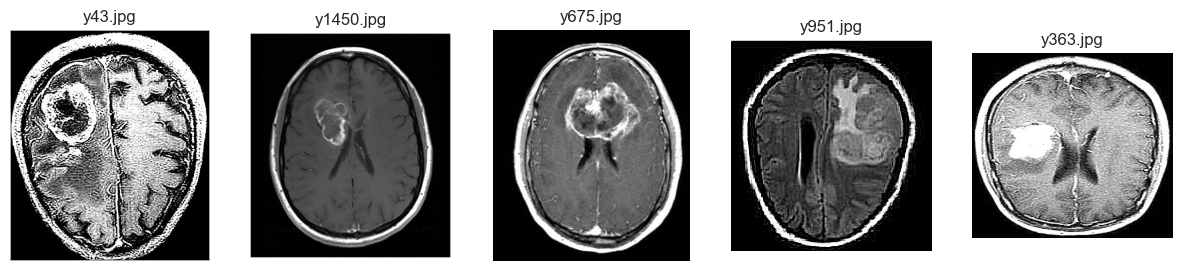

In [6]:
def show_random_samples(folder, n=5):
    plt.figure(figsize=(15,3))
    files = np.random.choice(os.listdir(folder), n, replace=False)
    for i, file in enumerate(files):
        img = Image.open(os.path.join(folder, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(file)
    plt.show()

# Show samples
show_random_samples(no_path)
show_random_samples(yes_path)

4️⃣ Image Shape Analysis

In [7]:
def get_image_shapes(folder):
    shapes = []
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        shapes.append(img.size)  # (width, height)
    return shapes

no_shapes = get_image_shapes(no_path)
yes_shapes = get_image_shapes(yes_path)

# Convert to numpy for analysis
no_shapes_arr = np.array(no_shapes)
yes_shapes_arr = np.array(yes_shapes)

print("No class image sizes stats:")
print(f"Unique sizes: {np.unique(no_shapes_arr, axis=0)}")

print("Yes class image sizes stats:")
print(f"Unique sizes: {np.unique(yes_shapes_arr, axis=0)}")


No class image sizes stats:
Unique sizes: [[ 150  198]
 [ 173  201]
 [ 177  197]
 [ 192  192]
 [ 194  259]
 [ 196  257]
 [ 200  243]
 [ 200  248]
 [ 200  252]
 [ 201  250]
 [ 201  251]
 [ 203  243]
 [ 205  214]
 [ 205  249]
 [ 206  244]
 [ 207  225]
 [ 207  243]
 [ 208  225]
 [ 208  242]
 [ 208  248]
 [ 208  278]
 [ 212  222]
 [ 212  236]
 [ 212  238]
 [ 214  236]
 [ 215  234]
 [ 218  231]
 [ 218  234]
 [ 220  212]
 [ 220  275]
 [ 222  252]
 [ 224  286]
 [ 225  225]
 [ 227  222]
 [ 227  262]
 [ 227  300]
 [ 228  221]
 [ 230  282]
 [ 232  217]
 [ 234  218]
 [ 234  224]
 [ 234  225]
 [ 235  214]
 [ 235  227]
 [ 235  228]
 [ 235  229]
 [ 235  261]
 [ 236  213]
 [ 236  218]
 [ 236  228]
 [ 236  231]
 [ 236  236]
 [ 236  243]
 [ 236  257]
 [ 236  260]
 [ 236  262]
 [ 236  263]
 [ 236  273]
 [ 236  290]
 [ 236  295]
 [ 236  300]
 [ 236  309]
 [ 236  357]
 [ 259  194]
 [ 267  328]
 [ 275  183]
 [ 275  301]
 [ 276  326]
 [ 300  168]
 [ 331  406]
 [ 332  442]
 [ 336  380]
 [ 339  340]
 [ 339  4

5️⃣ Pixel Intensity Distribution

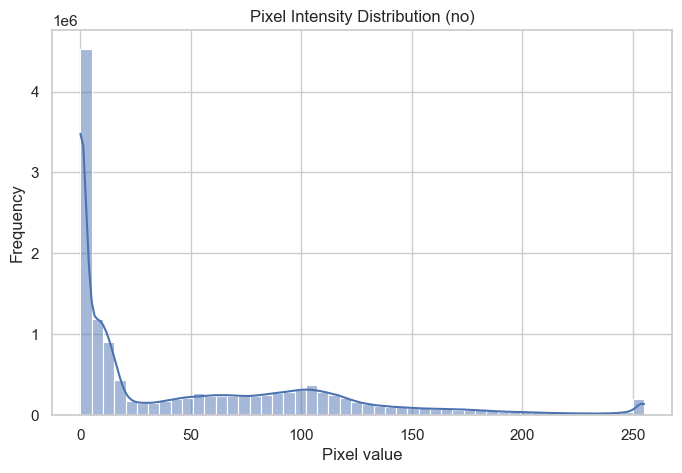

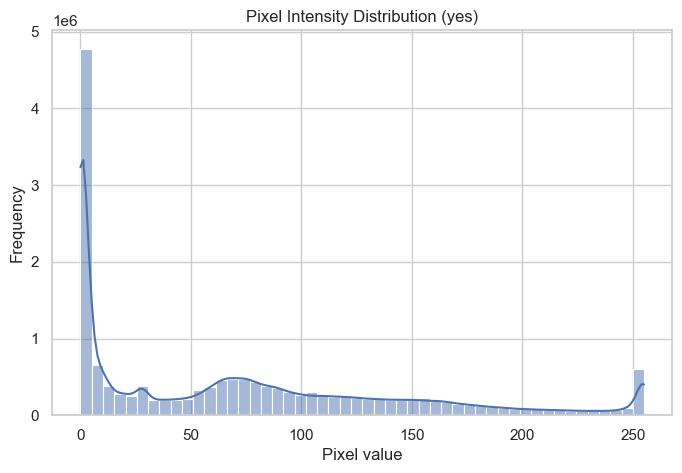

In [8]:
def plot_pixel_distribution(folder, n=100):
    pixels = []
    for file in np.random.choice(os.listdir(folder), n, replace=False):
        img = np.array(Image.open(os.path.join(folder, file)).convert('L'))
        pixels.extend(img.flatten())
    plt.figure(figsize=(8,5))
    sns.histplot(pixels, bins=50, kde=True)
    plt.title(f'Pixel Intensity Distribution ({folder.split("/")[-1]})')
    plt.xlabel('Pixel value')
    plt.ylabel('Frequency')
    plt.show()

plot_pixel_distribution(no_path)
plot_pixel_distribution(yes_path)


6️⃣ Class Balance Check

  class  num_images
0    no        1500
1   yes        1500


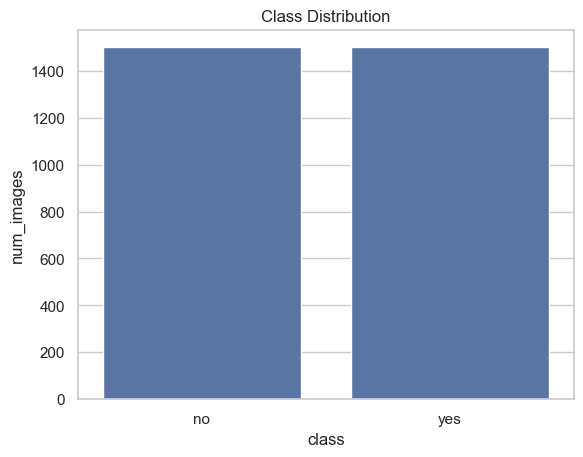

In [9]:
data_summary = pd.DataFrame({
    'class': ['no', 'yes'],
    'num_images': [len(no_images), len(yes_images)]
})
print(data_summary)

sns.barplot(x='class', y='num_images', data=data_summary)
plt.title('Class Distribution')
plt.show()
